In [176]:
import pandas as pd 
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import joblib

In [18]:
cosum= pd.read_excel(r"C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLRegression_Project - Copy\data\input\CreditConsumptionData.xlsx")
behav= pd.read_excel(r"C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLRegression_Project - Copy\data\input\CustomerBehaviorData.xlsx")
demog= pd.read_excel(r"C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLRegression_Project - Copy\data\input\CustomerDemographics.xlsx")

In [19]:
cosum.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       20000 non-null  int64  
 1   cc_cons  15000 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 312.6 KB


In [20]:
behav.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 39 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     20000 non-null  int64  
 1   cc_cons_apr            20000 non-null  float64
 2   dc_cons_apr            20000 non-null  float64
 3   cc_cons_may            19999 non-null  float64
 4   dc_cons_may            19999 non-null  float64
 5   cc_cons_jun            20000 non-null  float64
 6   dc_cons_jun            19999 non-null  float64
 7   cc_count_apr           19999 non-null  float64
 8   cc_count_may           20000 non-null  int64  
 9   cc_count_jun           20000 non-null  int64  
 10  dc_count_apr           20000 non-null  int64  
 11  dc_count_may           20000 non-null  int64  
 12  dc_count_jun           20000 non-null  int64  
 13  card_lim               20000 non-null  int64  
 14  personal_loan_active   20000 non-null  int64  
 15  vehicle_loan_

In [21]:
demog.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            20000 non-null  int64  
 1   account_type                  20000 non-null  object 
 2   gender                        20000 non-null  object 
 3   age                           20000 non-null  int64  
 4   Income                        20000 non-null  object 
 5   Emp_Tenure_Years              20000 non-null  float64
 6   Tenure_with_Bank              20000 non-null  int64  
 7   region_code                   20000 non-null  int64  
 8   NetBanking_Flag               20000 non-null  int64  
 9   Avg_days_between_transaction  20000 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 1.5+ MB


In [22]:
# Merging the Dataset
cust_360 = pd.merge(demog, behav, on='ID', how='left')
cust_360 = pd.merge(cust_360, cosum, on='ID', how='left')

In [23]:
#meta data inspection
cust_360.shape

(20000, 49)

In [ ]:
#encoding categorical columns
cust_360 = pd.get_dummies(cust_360,columns=['account_type', 'gender', 'Income'],drop_first=True,dtype=int)

In [33]:
# mapping values in column
cust_360['loan_enq'] = cust_360['loan_enq'].map({'Y':1, 'N':0})

In [36]:
# filling missing values 
cust_360['loan_enq'] = cust_360['loan_enq'].fillna(cust_360['loan_enq'].median())

In [38]:
# seprate target variable 
target = cust_360['cc_cons']
cust_360 = cust_360.drop(columns=['cc_cons'])

In [39]:
# now fill missing values in numeric columns
cust_360 = cust_360.fillna(cust_360.median())

In [41]:
# merging back the target variable in cust360
cust_360['cc_cons'] = target

In [42]:
#checking missing values  
cust_360.isnull().sum().sort_values(ascending=False).head(10)

cc_cons                         5000
age                                0
Emp_Tenure_Years                   0
Tenure_with_Bank                   0
ID                                 0
NetBanking_Flag                    0
Avg_days_between_transaction       0
cc_cons_apr                        0
dc_cons_apr                        0
cc_cons_may                        0
dtype: int64

In [43]:
# checking duplicated records
cust_360.duplicated().sum()

np.int64(0)

Feature Engineering

In [44]:
#Total Credit Spend
cust_360['total_cc_spend'] = cust_360[['cc_cons_apr','cc_cons_may','cc_cons_jun']].sum(axis=1)

In [45]:
#Avg Credit Spend
cust_360['avg_cc_spend'] = cust_360['total_cc_spend'] / 3

In [46]:
#Credit Spend Trend
cust_360['cc_spend_trend'] = cust_360['cc_cons_jun'] - cust_360['cc_cons_apr']

In [47]:
#Total Credit Transactions
cust_360['total_cc_txn'] = cust_360[['cc_count_apr','cc_count_may','cc_count_jun']].sum(axis=1)

In [48]:
#Avg Spend per Credit Transaction
cust_360['avg_cc_txn_value'] = cust_360['total_cc_spend'] / (cust_360['total_cc_txn'] + 1)

In [49]:
#Credit Utilization
cust_360['credit_utilization'] = cust_360['total_cc_spend'] / (cust_360['card_lim'] + 1)

In [50]:
#Debit vs Credit Preference
cust_360['cc_dc_ratio'] = cust_360['total_cc_spend'] / (cust_360[['dc_cons_apr','dc_cons_may','dc_cons_jun']].sum(axis=1) + 1)

In [51]:
#Activity Level
cust_360['total_txn'] = cust_360[['cc_count_apr','cc_count_may','cc_count_jun','dc_count_apr','dc_count_may','dc_count_jun']].sum(axis=1)

In [52]:
#Transaction Consistency
cust_360['txn_consistency'] = cust_360[['cc_count_apr','cc_count_may','cc_count_jun']].std(axis=1)

In [54]:
# split available and unavailable data
train_data = cust_360[cust_360['cc_cons'].notnull()]
pred_data  = cust_360[cust_360['cc_cons'].isnull()]

In [57]:
# separting variables and target
X = train_data.drop(['cc_cons', 'ID'], axis=1)
y = train_data['cc_cons']

In [58]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear regression model

In [60]:
#standardizing the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [64]:
#using RFE for best feature selection
rfe = RFE(LinearRegression(), n_features_to_select=20)  
rfe.fit(X_train_scaled, y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",20
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [66]:
selected_features = X_train.columns[rfe.support_]

In [68]:
X_train_rfe = X_train[selected_features]
X_test_rfe  = X_test[selected_features]

In [ ]:
# train and test with selected features
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe)
X_test_rfe_scaled  = scaler.transform(X_test_rfe)

In [69]:
#Scale AGAIN
X_train_rfe_scaled = scaler.fit_transform(X_train_rfe)
X_test_rfe_scaled  = scaler.transform(X_test_rfe)

In [70]:
# intitate and fit the model 
Lr = LinearRegression()

In [72]:
Lr.fit(X_train_rfe_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [88]:
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

In [91]:
#train rseults
print("Train R2:", r2_score(y_train, Lr.predict(X_train_rfe_scaled)))
print("Train RMSPE:", rmspe(y_train, Lr.predict(X_train_rfe_scaled)))

Train R2: 0.8760383601682714
Train RMSPE: 0.26856381947090263


In [92]:
#test results
print("Test R2:", r2_score(y_test, Lr.predict(X_test_rfe_scaled)))
print("Test RMSPE:", rmspe(y_test, Lr.predict(X_test_rfe_scaled)))

Train R2: 0.8649869284209422
Train RMSPE: 0.2683108353009438


DecisonTree

In [94]:
dt = DecisionTreeRegressor(max_depth=5,min_samples_split=50,min_samples_leaf=20,random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [96]:
#train rseults
print("Train R2:", r2_score(y_train, dt.predict(X_train)))
print("Train RMSPE:", rmspe(y_train, dt.predict(X_train)))

Train R2: 0.7355364475136071
Train RMSPE: 0.4537044785955896


In [97]:
#test rseults
print("Test R2:", r2_score(y_test, dt.predict(X_test)))
print("Test RMSPE:", rmspe(y_test, dt.predict(X_test)))

Train R2: 0.7460385370160837
Train RMSPE: 0.4598377558499865


RandomForest

In [103]:
rf = RandomForestRegressor(n_estimators=200,max_depth=10,min_samples_split=50,min_samples_leaf=20,random_state=42,n_jobs=-1)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [104]:
#train rseults
print("Train R2:", r2_score(y_train, rf.predict(X_train)))
print("Train RMSPE:", rmspe(y_train, rf.predict(X_train)))

Train R2: 0.8044517141840404
Train RMSPE: 0.2702635776162592


In [105]:
#test rseults
print("Test R2:", r2_score(y_test, rf.predict(X_test)))
print("Test RMSPE:", rmspe(y_test, rf.predict(X_test)))

Train R2: 0.8387758404511793
Train RMSPE: 0.2848229062175926


XGBoost

In [117]:
xgb = XGBRegressor(n_estimators=500,learning_rate=0.03,max_depth=3,subsample=0.8,colsample_bytree=0.8,random_state=42)
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [118]:
#train rseults
print("Train R2:", r2_score(y_train, xgb.predict(X_train)))
print("Train RMSPE:", rmspe(y_train, xgb.predict(X_train)))

Train R2: 0.8996430448691526
Train RMSPE: 0.2617152952363597


In [119]:
#test rseults
print("Test R2:", r2_score(y_test, xgb.predict(X_test)))
print("Test RMSPE:", rmspe(y_test, xgb.predict(X_test)))

Train R2: 0.8468786069600261
Train RMSPE: 0.27319678110641005


LightGBM

In [ ]:
lgb = LGBMRegressor(n_estimators=500,learning_rate=0.03,max_depth=5,subsample=0.8,colsample_bytree=0.8,random_state=42)
lgb.fit(X_train, y_train)

In [128]:
#train rseults
print("Train R2:", r2_score(y_train, lgb.predict(X_train)))
print("Train RMSPE:", rmspe(y_train, lgb.predict(X_train)))

Train R2: 0.8934825552295743
Train RMSPE: 0.26040606077272127


In [129]:
#test rseults
print("Test R2:", r2_score(y_test, lgb.predict(X_test)))
print("Test RMSPE:", rmspe(y_test, lgb.predict(X_test)))

Train R2: 0.8481152839065753
Train RMSPE: 0.27969334285130293


CatBoost

In [134]:
cb = CatBoostRegressor(iterations=300,learning_rate=0.03,depth=4,l2_leaf_reg=10,random_state=42,verbose=0)
cb.fit(X_train, y_train)

CatBoostRegressor(depth=4, iterations=300, l2_leaf_reg=10, learning_rate=0.03, loss_function='RMSE', random_state=42, verbose=0)

In [135]:
#train rseults
print("Train R2:", r2_score(y_train, cb.predict(X_train)))
print("Train RMSPE:", rmspe(y_train, cb.predict(X_train)))

Train R2: 0.8467234712337989
Train RMSPE: 0.3137913655753743


In [136]:
#test rseults
print("Test R2:", r2_score(y_test, cb.predict(X_test)))
print("Test RMSPE:", rmspe(y_test, cb.predict(X_test)))

Train R2: 0.8531560867024188
Train RMSPE: 0.30481131840186687


“Customer credit consumption is influenced by both linear and non-linear behavioral patterns. While linear regression captures the overall trend effectively, ensemble models like CatBoost provide better robustness and adaptability, making them more suitable for real-world deployment.”

“After identifying the top-performing models, hyperparameter tuning was performed using GridSearchCV to further optimize model performance and improve generalization.”

GridSearchCV on Catboost

In [138]:
param_grid = {'depth': [4, 5, 6],'learning_rate': [0.03, 0.05],'iterations': [200, 300],'l2_leaf_reg': [3, 5, 10]}
grid = GridSearchCV(CatBoostRegressor(random_state=42,verbose=0),param_grid=param_grid,scoring='r2',cv=3,n_jobs=-1,verbose=1)

In [139]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","CatBoostRegre...42, verbose=0)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'depth': [4, 5, ...], 'iterations': [200, 300], 'l2_leaf_reg': [3, 5, ...], 'learning_rate': [0.03, 0.05]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is 

In [147]:
best_cb=grid.best_estimator_

In [148]:
#train rseults
print("Train R2:", r2_score(y_train,best_cb.predict(X_train)))
print("Train RMSPE:", rmspe(y_train, best_cb.predict(X_train)))

Train R2: 0.8869051548878306
Train RMSPE: 0.27122878295177627


In [149]:
#test rseults
print("Test R2:", r2_score(y_test,best_cb.predict(X_test)))
print("Test RMSPE:", rmspe(y_test,best_cb.predict(X_test)))

Train R2: 0.851864489280729
Train RMSPE: 0.27662419656095133


GridSearchCV on XGBoost

In [152]:
param_grid = {'n_estimators': [200, 300],'learning_rate': [0.03, 0.05],'max_depth': [3, 5],'subsample': [0.8],'colsample_bytree': [0.8]}
grid_xgb = GridSearchCV(estimator=xgb,param_grid=param_grid,scoring='r2',cv=3,n_jobs=-1,verbose=1)

In [153]:
grid_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.03, 0.05], 'max_depth': [3, 5], 'n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [154]:
best_xgb = grid_xgb.best_estimator_

In [155]:
#train rseults
print("Train R2:", r2_score(y_train,best_xgb.predict(X_train)))
print("Train RMSPE:", rmspe(y_train,best_xgb.predict(X_train)))

Train R2: 0.8983089878530298
Train RMSPE: 0.2615605994546378


In [157]:
#test rseults
print("Test R2:", r2_score(y_test,best_xgb.predict(X_test)))
print("Test RMSPE:", rmspe(y_test,best_xgb.predict(X_test)))

Test R2: 0.8444072864665243
Test RMSPE: 0.27296778314319237


“From the observed relationship between actual and predicted values, we can infer that the data exhibits a strong linear trend.”

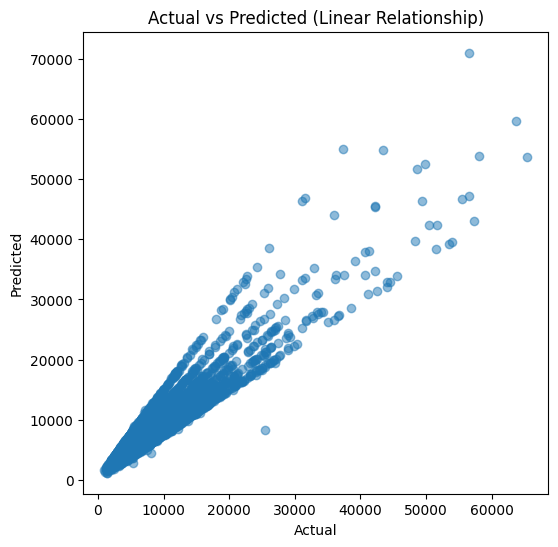

In [162]:
# Predictions from linear regression
y_pred_lr = Lr.predict(X_test_rfe_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Relationship)")

plt.show()

We’ll compare your top 3 models:
Linear Regression
CatBoost
XGBoost

In [163]:
model_names = ['Linear Regression', 'CatBoost', 'XGBoost']

r2_scores = [0.865, 0.852, 0.844]   # your test R2
rmspe_scores = [0.268, 0.276, 0.272]  # your test RMSPE

results = pd.DataFrame({
    'Model': model_names,
    'R2': r2_scores,
    'RMSPE': rmspe_scores
})

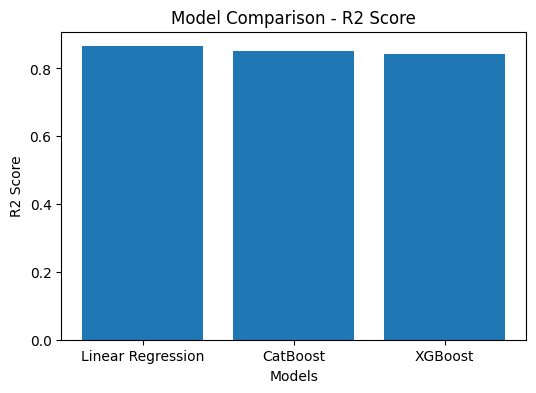

In [165]:
#bar chart r2
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['R2'])

plt.title("Model Comparison - R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.show()

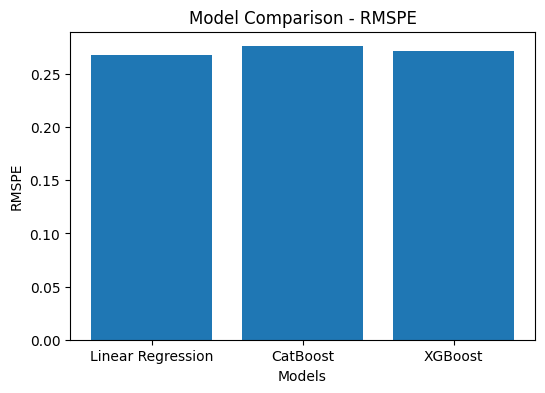

In [166]:
# bar chart RMSPE
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['RMSPE'])

plt.title("Model Comparison - RMSPE")
plt.xlabel("Models")
plt.ylabel("RMSPE")

plt.show()

“The results indicate that Linear Regression outperformed more complex models by achieving higher R², lower RMSPE, and reduced overfitting, suggesting that the underlying relationship in the data is largely linear.”

"Now Train the Model on full data for better predictions on unseen data."

In [169]:
# preprocessing on data and fit 
# Step 1: RFE on full data
rfe.fit(X, y)

selected_features = X.columns[rfe.support_]

X_full_rfe = X[selected_features]

# Step 2: Scaling
scaler.fit(X_full_rfe)
X_full_scaled = scaler.transform(X_full_rfe)

# Step 3: Train model
Lr.fit(X_full_scaled, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [170]:
#Apply SAME preprocessing on 5000 records
X_new = pred_data.drop(['cc_cons', 'ID'], axis=1)

In [171]:
# Select same features
X_new_rfe = X_new[selected_features]

In [172]:
# Scale
X_new_scaled = scaler.transform(X_new_rfe)

In [174]:
predictions = Lr.predict(X_new_scaled)

pred_data['predicted_cc_cons'] = predictions

In [175]:
# save the final predicted file 
predictions_df = pred_data.copy()
predictions_df.to_csv(r'C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLRegression_Project - Copy\data\output\new_predictions.csv',index=False)

In [177]:
# save the model using joblib for future predictions
joblib.dump({'model': Lr,'scaler': scaler,'selected_features': selected_features},r'C:\Users\ALISHA\Pictures\Screenshots\DATA SCIENCE REVISION\Machine Learning\MLRegression_Project - Copy\data\output\lr_model_pipeline.pkl')

['C:\\Users\\ALISHA\\Pictures\\Screenshots\\DATA SCIENCE REVISION\\Machine Learning\\MLRegression_Project - Copy\\data\\output\\lr_model_pipeline.pkl']